# Complete Pipeline — AAPL Sentiment-Enhanced Stock Prediction

End-to-end pipeline based on https://doi.org/10.3390/electronics12183960.

| Step | Description |
|---|---|
| 1 | Load AAPL OHLCV from `MarketDataCache` (2018 – 2020-06) |
| 2 | Load news headlines from `data/news_kaggle/` parquet files |
| 3 | Run BART + FinBERT sentiment pipeline |
| 4 | Build fused dataset (16 technical factors + 768-dim sentiment embeddings) |
| 5 | Train LSTM and Transformer — best settings from ablation study |
| 6 | Bootstrap evaluation with 95% CIs |
| 7 | Real price vs predicted strategy visualisation |

**Ablation-study defaults:** window=64, LSTM MLP head, Transformer n_layers=6, momentum slope gate at inference.

In [8]:
from sentiment.log import setup_logging
setup_logging()

## 0. Imports and constants

In [9]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_auc_score, accuracy_score

from sentiment.sources.cache import MarketDataCache
from sentiment.features.technical import TechnicalFactors
from sentiment.features.dataloader import build_dataset, make_loaders
from sentiment.features.screening import momentum_slope
from sentiment.embeddings import SentimentPipeline
from sentiment.model import (
    SentimentLSTM,
    SentimentTransformer,
    train_model,
    evaluate,
    bootstrap_evaluate,
    collect_predictions,
)

TICKER = "AAPL"
START  = pd.Timestamp("2018-01-01", tz="UTC")
END    = pd.Timestamp("2020-06-30", tz="UTC")
WINDOW = 64          # best from ablation Exp 1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"device : {DEVICE}")
print(f"ticker : {TICKER}")
print(f"range  : {START.date()} → {END.date()}")
print(f"window : {WINDOW}")

C:\Users\dnjs2\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device : cpu
ticker : AAPL
range  : 2018-01-01 → 2020-06-30
window : 64


## 1. Market Data — Load AAPL from cache

In [10]:
cache = MarketDataCache()
market_dfs = []
for yr in [2018, 2019, 2020]:
    market_dfs.append(cache.load(TICKER, yr))

df = pd.concat(market_dfs).sort_index()
df = df[(df.index >= START) & (df.index <= END)]

print(f"Market rows : {len(df)}")
print(f"Date range  : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Columns     : {df.columns.tolist()}")
df[["open", "high", "low", "close", "volume", "vwap"]].tail()

Market rows : 625
Date range  : 2018-01-02 → 2020-06-29
Columns     : ['symbol', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap']


,open,high,low,close,volume,vwap
timestamp,,,,,,
2020-06-23 04:00:00+00:00,91.00,93.10,90.57,91.63,221105148,91.93
2020-06-24 04:00:00+00:00,91.25,92.20,89.63,90.02,201825600,90.55
2020-06-25 04:00:00+00:00,90.18,91.25,89.39,91.21,144038328,90.50
2020-06-26 04:00:00+00:00,91.10,91.33,88.26,88.41,229739612,89.24
2020-06-29 04:00:00+00:00,88.31,90.54,87.82,90.45,138974260,89.69


## 2. News Data — Load from Kaggle parquet files

Monthly parquet files in `data/news_kaggle/` share the same Article schema as
`ArticleRepository` (id, url, title, text, publish_date, source_name, language, tickers).
AAPL coverage starts from 2020-03; earlier dates fall back to zero-vector sentinel embeddings.

In [11]:
NEWS_DIR   = Path("../data/news_kaggle")
START_DATE = START.date()
END_DATE   = END.date()

article_rows = []
for path in sorted(NEWS_DIR.glob("*.parquet")):
    monthly = pd.read_parquet(path)
    mask = monthly["tickers"].apply(
        lambda t: (TICKER in t) if t is not None else False
    )
    aapl = monthly[mask]
    if not aapl.empty:
        article_rows.append(aapl)

if article_rows:
    news_df = pd.concat(article_rows, ignore_index=True)
    news_df["publish_date"] = pd.to_datetime(news_df["publish_date"]).dt.date
    news_df = news_df[
        (news_df["publish_date"] >= START_DATE) &
        (news_df["publish_date"] <= END_DATE)
    ].reset_index(drop=True)
    print(f"AAPL articles : {len(news_df)}")
    print(f"Date range    : {news_df['publish_date'].min()} → {news_df['publish_date'].max()}")
    monthly_counts = (
        news_df.groupby(news_df["publish_date"].apply(lambda d: d.strftime("%Y-%m")))
        .size().rename("articles")
    )
    print("\nArticles per month:")
    print(monthly_counts.to_string())
else:
    news_df = pd.DataFrame()
    print("No AAPL articles found — sentiment features will be zero vectors")

AAPL articles : 463
Date range    : 2020-03-09 → 2020-06-02

Articles per month:
publish_date
2020-03    130
2020-04    166
2020-05    149
2020-06     18


## 3. Sentiment Analysis — BART summarisation + FinBERT encoding

Model loading takes ~30 s on first run (downloads from Hugging Face).

In [12]:
print("Loading SentimentPipeline (BART-large-cnn + FinBERT) …")
pipe = SentimentPipeline(device=DEVICE)
print("Models loaded.")

Loading SentimentPipeline (BART-large-cnn + FinBERT) …


23:06:35 INFO     httpx  HTTP Request: HEAD https://huggingface.co/facebook/bart-large-cnn/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
23:06:35 INFO     httpx  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-large-cnn/37f520fa929c961707657b28798b30c003dd100b/config.json "HTTP/1.1 200 OK"
23:06:35 INFO     httpx  HTTP Request: HEAD https://huggingface.co/facebook/bart-large-cnn/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
23:06:35 WARNING  huggingface_hub.utils._http  Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
23:06:35 INFO     httpx  HTTP Request: HEAD https://huggingface.co/facebook/bart-large-cnn/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
23:06:35 INFO     httpx  HTTP Request: GET https://huggingface.co/api/models/facebook/bart-large-cnn/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 

Models loaded.


In [13]:
if not news_df.empty:
    articles = news_df.to_dict("records")
    for a in articles:
        if hasattr(a.get("tickers"), "tolist"):
            a["tickers"] = a["tickers"].tolist()

    print(f"Processing {len(articles)} articles through BART + FinBERT …")
    daily_sentiment = pipe.process_ticker_articles({TICKER: articles})
    print(f"Daily sentiment: {len(daily_sentiment)} ticker-days")
    display(
        daily_sentiment[["ticker", "date", "sentiment_score", "n_articles"]]
        .sort_values("date").reset_index(drop=True)
    )
else:
    daily_sentiment = None
    print("No articles — sentiment_df=None (zero-vector fallback in build_dataset)")

23:06:40 INFO     httpx  HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors "HTTP/1.1 302 Found"


Processing 463 articles through BART + FinBERT …
Daily sentiment: 79 ticker-days


,ticker,date,sentiment_score,n_articles
0,AAPL,2020-03-09,0.333333,3
1,AAPL,2020-03-10,0.375000,8
2,AAPL,2020-03-11,0.285714,14
3,AAPL,2020-03-12,0.500000,5
4,AAPL,2020-03-13,0.545455,11
...,...,...,...,...
74,AAPL,2020-05-29,0.250000,6
75,AAPL,2020-05-30,0.416667,6
76,AAPL,2020-05-31,0.437500,8
77,AAPL,2020-06-01,0.500000,9


## 4. Build Fused Dataset

Combines:
- 16 technical indicators (trend, momentum, volatility, volume, returns)
- 768-dim FinBERT sentiment embeddings (zero vector on days without news)
- 3-dim FinBERT softmax probabilities at window end date

In [14]:
technical = TechnicalFactors()
dataset = build_dataset(
    df, technical,
    sentiment_df=daily_sentiment,
    ticker=TICKER,
    window=WINDOW,
)

N       = len(dataset["y"])
N_SPROB = dataset["X_sentiment_probs"].shape[1]   # 3 when sentiment enabled

n_pos_all = int(dataset["y"].sum())
n_neg_all = N - n_pos_all

print(f"Total windows      : {N}")
print(f"X_tech shape       : {dataset['X_tech'].shape}")
print(f"X_sentiment shape  : {dataset['X_sentiment'].shape}")
print(f"X_sent_probs shape : {dataset['X_sentiment_probs'].shape}  (N_SPROB={N_SPROB})")
print(f"Labels             : pos={n_pos_all} ({n_pos_all/N:.1%}), neg={n_neg_all} ({n_neg_all/N:.1%})")

23:07:47 INFO     sentiment.features.dataloader  Built dataset: 501 windows, 16 tech factors, 0 fundamental factors, 3 sentiment prob features, window=64


Total windows      : 501
X_tech shape       : (501, 64, 16)
X_sentiment shape  : (501, 64, 768)
X_sent_probs shape : (501, 3)  (N_SPROB=3)
Labels             : pos=313 (62.5%), neg=188 (37.5%)


In [15]:
train_loader, val_loader, test_loader, tech_scaler, _ = make_loaders(
    dataset, test_frac=0.2, val_frac=0.1, batch_size=32
)

# Reproduce split indices for pos_weight (mirrors make_loaders internals)
test_start = int(N * 0.8)
val_start  = int(test_start * 0.9)
y_train    = dataset["y"][:val_start]
n_pos      = int(y_train.sum())
n_neg      = len(y_train) - n_pos
pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

print(f"Split — train: {val_start}, val: {test_start - val_start}, test: {N - test_start}")
print(f"Train balance — pos: {n_pos} ({n_pos/len(y_train):.1%}),  neg: {n_neg}")
print(f"pos_weight : {pos_weight:.3f}")

23:07:47 INFO     sentiment.features.dataloader  Split sizes — train: 360, val: 40, test: 101


Split — train: 360, val: 40, test: 101
Train balance — pos: 219 (60.8%),  neg: 141
pos_weight : 0.644


## 5. LSTM Model

Best settings from ablation study:
- **Window = 64** (Exp 1: longer window improves AUC)
- **MLP head** `Linear→ReLU→Dropout→BN→Linear` (Exp 3: outperforms single Linear)

In [16]:
lstm_model = SentimentLSTM(n_sentiment_probs=N_SPROB)

print("Training LSTM (window=64, MLP head) …")
lstm_history = train_model(
    lstm_model, train_loader, val_loader,
    n_epochs=100, patience=15,
    device=DEVICE, seed=SEED,
    pos_weight=pos_weight,
)
print(f"  best epoch {lstm_history['best_epoch']}  val_auc={lstm_history['best_val_auc']:.4f}")

Training LSTM (window=64, MLP head) …


23:07:48 INFO     sentiment.model.train  Epoch   1 | train_loss=0.5379 | val_loss=0.6381 | val_auc=0.4570 | val_acc=0.8000
23:07:49 INFO     sentiment.model.train  Epoch   2 | train_loss=0.5557 | val_loss=0.6351 | val_auc=0.5898 | val_acc=0.8000
23:07:50 INFO     sentiment.model.train  Epoch   3 | train_loss=0.5453 | val_loss=0.6309 | val_auc=0.5938 | val_acc=0.8000
23:07:51 INFO     sentiment.model.train  Epoch   4 | train_loss=0.5275 | val_loss=0.6408 | val_auc=0.5078 | val_acc=0.8000
23:07:52 INFO     sentiment.model.train  Epoch   5 | train_loss=0.5304 | val_loss=0.6470 | val_auc=0.4609 | val_acc=0.7000
23:07:53 INFO     sentiment.model.train  Epoch   6 | train_loss=0.5216 | val_loss=0.6419 | val_auc=0.4688 | val_acc=0.6500
23:07:54 INFO     sentiment.model.train  Epoch   7 | train_loss=0.5125 | val_loss=0.7664 | val_auc=0.4102 | val_acc=0.4000
23:07:55 INFO     sentiment.model.train  Epoch   8 | train_loss=0.5022 | val_loss=0.7978 | val_auc=0.4062 | val_acc=0.4250
23:07:55 INFO   

  best epoch 3  val_auc=0.5938


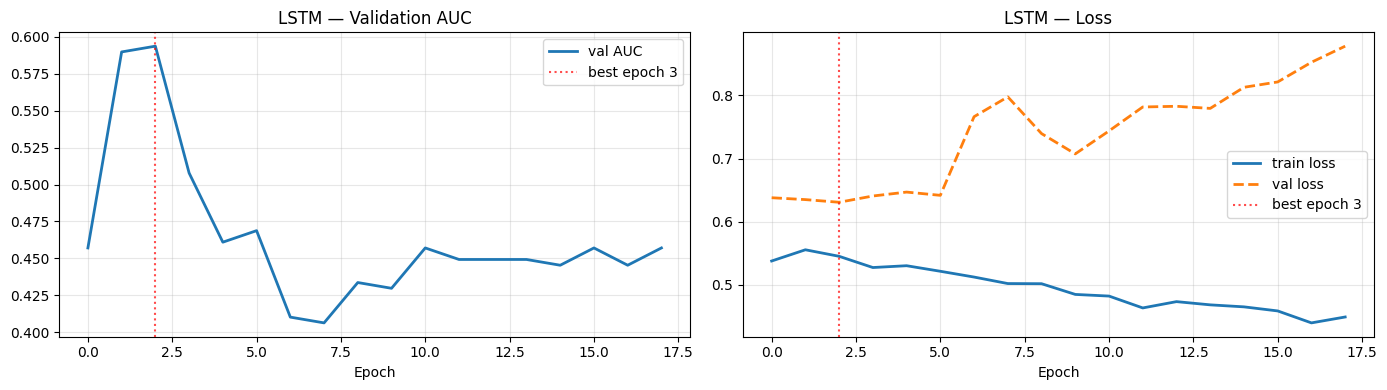

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_history["val_auc"], linewidth=2, label="val AUC")
axes[0].axvline(
    lstm_history["best_epoch"] - 1, color="red", linestyle=":", alpha=0.7,
    label=f"best epoch {lstm_history['best_epoch']}"
)
axes[0].set_title("LSTM — Validation AUC")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lstm_history["train_loss"], linewidth=2, label="train loss")
axes[1].plot(lstm_history["val_loss"],   linewidth=2, linestyle="--", label="val loss")
axes[1].axvline(
    lstm_history["best_epoch"] - 1, color="red", linestyle=":", alpha=0.7,
    label=f"best epoch {lstm_history['best_epoch']}"
)
axes[1].set_title("LSTM — Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Transformer Model

Best settings from ablation study:
- **Window = 64** (same as LSTM)
- **n_layers = 6** (Exp 2: matches reference paper, best test AUC)

In [18]:
tf_model = SentimentTransformer(n_layers=6, n_sentiment_probs=N_SPROB)

print("Training Transformer (n_layers=6, window=64) …")
tf_history = train_model(
    tf_model, train_loader, val_loader,
    n_epochs=100, patience=15,
    device=DEVICE, seed=SEED,
    pos_weight=pos_weight,
)
print(f"  best epoch {tf_history['best_epoch']}  val_auc={tf_history['best_val_auc']:.4f}")

Training Transformer (n_layers=6, window=64) …


23:08:10 INFO     sentiment.model.train  Epoch   1 | train_loss=0.6175 | val_loss=0.8695 | val_auc=0.3242 | val_acc=0.2000
23:08:15 INFO     sentiment.model.train  Epoch   2 | train_loss=0.5476 | val_loss=0.7658 | val_auc=0.8203 | val_acc=0.2000
23:08:19 INFO     sentiment.model.train  Epoch   3 | train_loss=0.5562 | val_loss=0.6871 | val_auc=0.8320 | val_acc=0.8500
23:08:23 INFO     sentiment.model.train  Epoch   4 | train_loss=0.5535 | val_loss=0.8156 | val_auc=0.8203 | val_acc=0.2000
23:08:27 INFO     sentiment.model.train  Epoch   5 | train_loss=0.5419 | val_loss=0.7796 | val_auc=0.8281 | val_acc=0.2000
23:08:32 INFO     sentiment.model.train  Epoch   6 | train_loss=0.5342 | val_loss=1.2571 | val_auc=0.8281 | val_acc=0.2000
23:08:38 INFO     sentiment.model.train  Epoch   7 | train_loss=0.5325 | val_loss=0.6952 | val_auc=0.4180 | val_acc=0.4250
23:08:42 INFO     sentiment.model.train  Epoch   8 | train_loss=0.5518 | val_loss=0.6785 | val_auc=0.7227 | val_acc=0.8000
23:08:47 INFO   

  best epoch 25  val_auc=0.8789


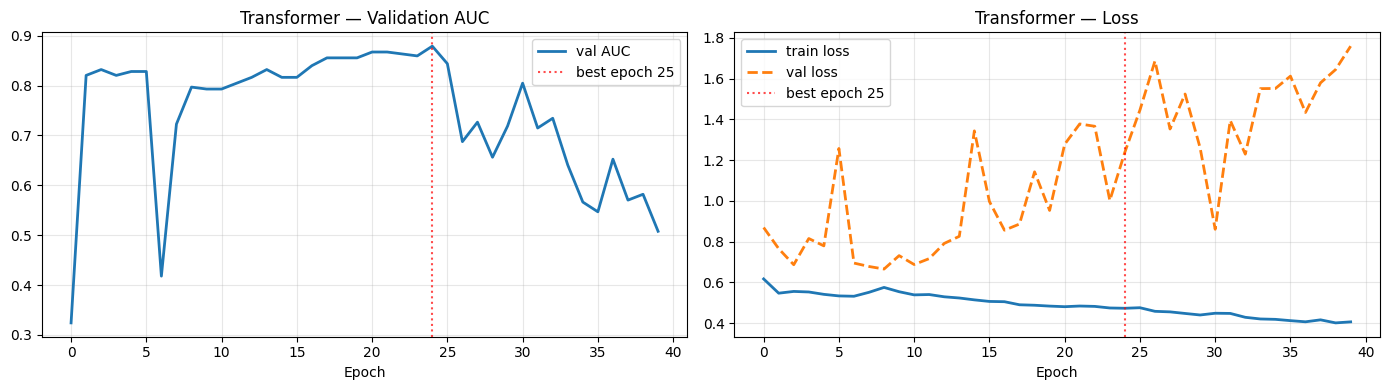

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(tf_history["val_auc"], linewidth=2, label="val AUC")
axes[0].axvline(
    tf_history["best_epoch"] - 1, color="red", linestyle=":", alpha=0.7,
    label=f"best epoch {tf_history['best_epoch']}"
)
axes[0].set_title("Transformer — Validation AUC")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(tf_history["train_loss"], linewidth=2, label="train loss")
axes[1].plot(tf_history["val_loss"],   linewidth=2, linestyle="--", label="val loss")
axes[1].axvline(
    tf_history["best_epoch"] - 1, color="red", linestyle=":", alpha=0.7,
    label=f"best epoch {tf_history['best_epoch']}"
)
axes[1].set_title("Transformer — Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Bootstrap Evaluation

95% confidence intervals via 1000 bootstrap resamples of the test set.
Non-overlapping CIs indicate a statistically significant difference.

In [20]:
def fmt_ci(r, m):
    return f"{r[f'{m}_mean']:.4f}  [{r[f'{m}_ci_low']:.4f} – {r[f'{m}_ci_high']:.4f}]"

metrics = ["auc", "accuracy", "precision", "recall"]

print("Evaluating LSTM …")
bs_lstm = bootstrap_evaluate(lstm_model, test_loader, device=DEVICE, n_bootstrap=1000, seed=SEED)

print("Evaluating Transformer …")
bs_tf = bootstrap_evaluate(tf_model, test_loader, device=DEVICE, n_bootstrap=1000, seed=SEED)

results_df = pd.DataFrame(
    {
        m: {
            "LSTM (window=64, MLP head)": fmt_ci(bs_lstm, m),
            "Transformer (n_layers=6)":  fmt_ci(bs_tf,   m),
        }
        for m in metrics
    }
).T
results_df.index.name = "metric"

print("\n95% bootstrap confidence intervals (n_bootstrap=1000)")
display(results_df)

Evaluating LSTM …
Evaluating Transformer …

95% bootstrap confidence intervals (n_bootstrap=1000)


,"LSTM (window=64, MLP head)",Transformer (n_layers=6)
metric,,
auc,0.5394 [0.4286 – 0.6538],0.7106 [0.5868 – 0.8127]
accuracy,0.5362 [0.4356 – 0.6339],0.7024 [0.6040 – 0.7921]
precision,0.6471 [0.5098 – 0.7843],0.7277 [0.6190 – 0.8333]
recall,0.5330 [0.4032 – 0.6607],0.8212 [0.7182 – 0.9181]


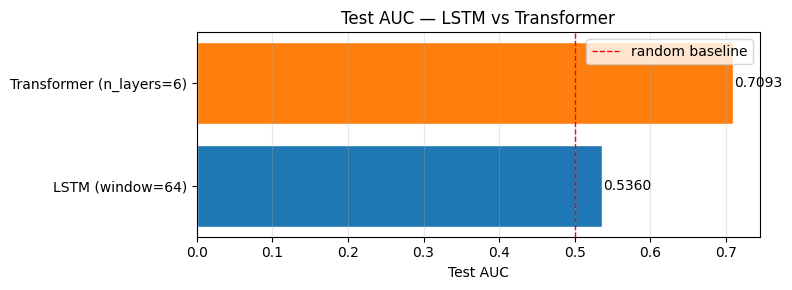

In [21]:
labels = ["LSTM (window=64)", "Transformer (n_layers=6)"]
aucs   = [
    evaluate(lstm_model, test_loader, device=DEVICE)["auc"],
    evaluate(tf_model,   test_loader, device=DEVICE)["auc"],
]

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(labels, aucs, color=["C0", "C1"], edgecolor="white")
ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="random baseline")
for bar, auc in zip(bars, aucs):
    ax.text(auc + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{auc:.4f}", va="center", fontsize=10)
ax.set_xlabel("Test AUC")
ax.set_title("Test AUC — LSTM vs Transformer")
ax.legend()
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Real Price vs Predicted Price

The model outputs **P(up)** for each rolling window.  We convert this to a
long/cash trading signal:

- **Long (pred ≥ 0.5):** hold AAPL — earn the day's actual return.
- **Cash (pred < 0.5):** stay flat — earn 0.

The **model strategy value** is compared against the **actual AAPL close price**
(buy-and-hold) over the test period.  A **20-day momentum slope gate** (Ablation
Exp 4) is also overlaid: only act when the 20-day linear-regression slope of
close prices is positive (uptrend).

In [22]:
probs_lstm, targets_arr = collect_predictions(lstm_model, test_loader, DEVICE)
probs_tf,   _           = collect_predictions(tf_model,   test_loader, DEVICE)

# Select model with higher validation AUC
if lstm_history["best_val_auc"] >= tf_history["best_val_auc"]:
    best_probs, best_name = probs_lstm, "LSTM"
else:
    best_probs, best_name = probs_tf,   "Transformer"

preds = (best_probs >= 0.5).astype(int)
print(f"Best model by val AUC : {best_name}")
print(f"Test windows          : {len(preds)}")
print(f"Long signals          : {preds.sum()} ({preds.mean():.1%})")

Best model by val AUC : Transformer
Test windows          : 101
Long signals          : 70 (69.3%)


In [23]:
# Momentum slope gate — Ablation Exp 4
# Only act on model signal when 20-day slope is positive (uptrend).

close_series = df["close"].copy()
if close_series.index.tz is not None:
    close_series.index = close_series.index.tz_convert(None)

test_dates_raw = dataset["dates"][test_start:]
test_dates_idx = pd.DatetimeIndex(test_dates_raw)
if test_dates_idx.tz is not None:
    test_dates_idx = test_dates_idx.tz_convert(None)

slopes = []
for d in test_dates_idx:
    loc = close_series.index.get_indexer([d], method="pad")[0]
    if loc < 20:
        slopes.append(0.0)
    else:
        win_closes = close_series.iloc[loc - 19 : loc + 1]
        slopes.append(momentum_slope(win_closes, window=20))

slopes       = np.array(slopes)
uptrend_mask = slopes > 0
preds_gated  = preds * uptrend_mask.astype(int)

print(f"Uptrend windows  : {uptrend_mask.sum()} / {len(uptrend_mask)} ({uptrend_mask.mean():.1%})")
print(f"Ungated long     : {preds.sum()}")
print(f"Gated long       : {preds_gated.sum()}")

Uptrend windows  : 69 / 101 (68.3%)
Ungated long     : 70
Gated long       : 55


In [24]:
# Price series aligned to test window dates
actual_test_prices = close_series.reindex(test_dates_idx, method="pad")
daily_rets         = actual_test_prices.pct_change().fillna(0.0).values

p0          = float(actual_test_prices.iloc[0])
actual_vals = actual_test_prices.values
strat_vals  = p0 * (1 + daily_rets * preds).cumprod()        # ungated strategy
gated_vals  = p0 * (1 + daily_rets * preds_gated).cumprod()  # momentum-gated

full_close = close_series  # for context panel

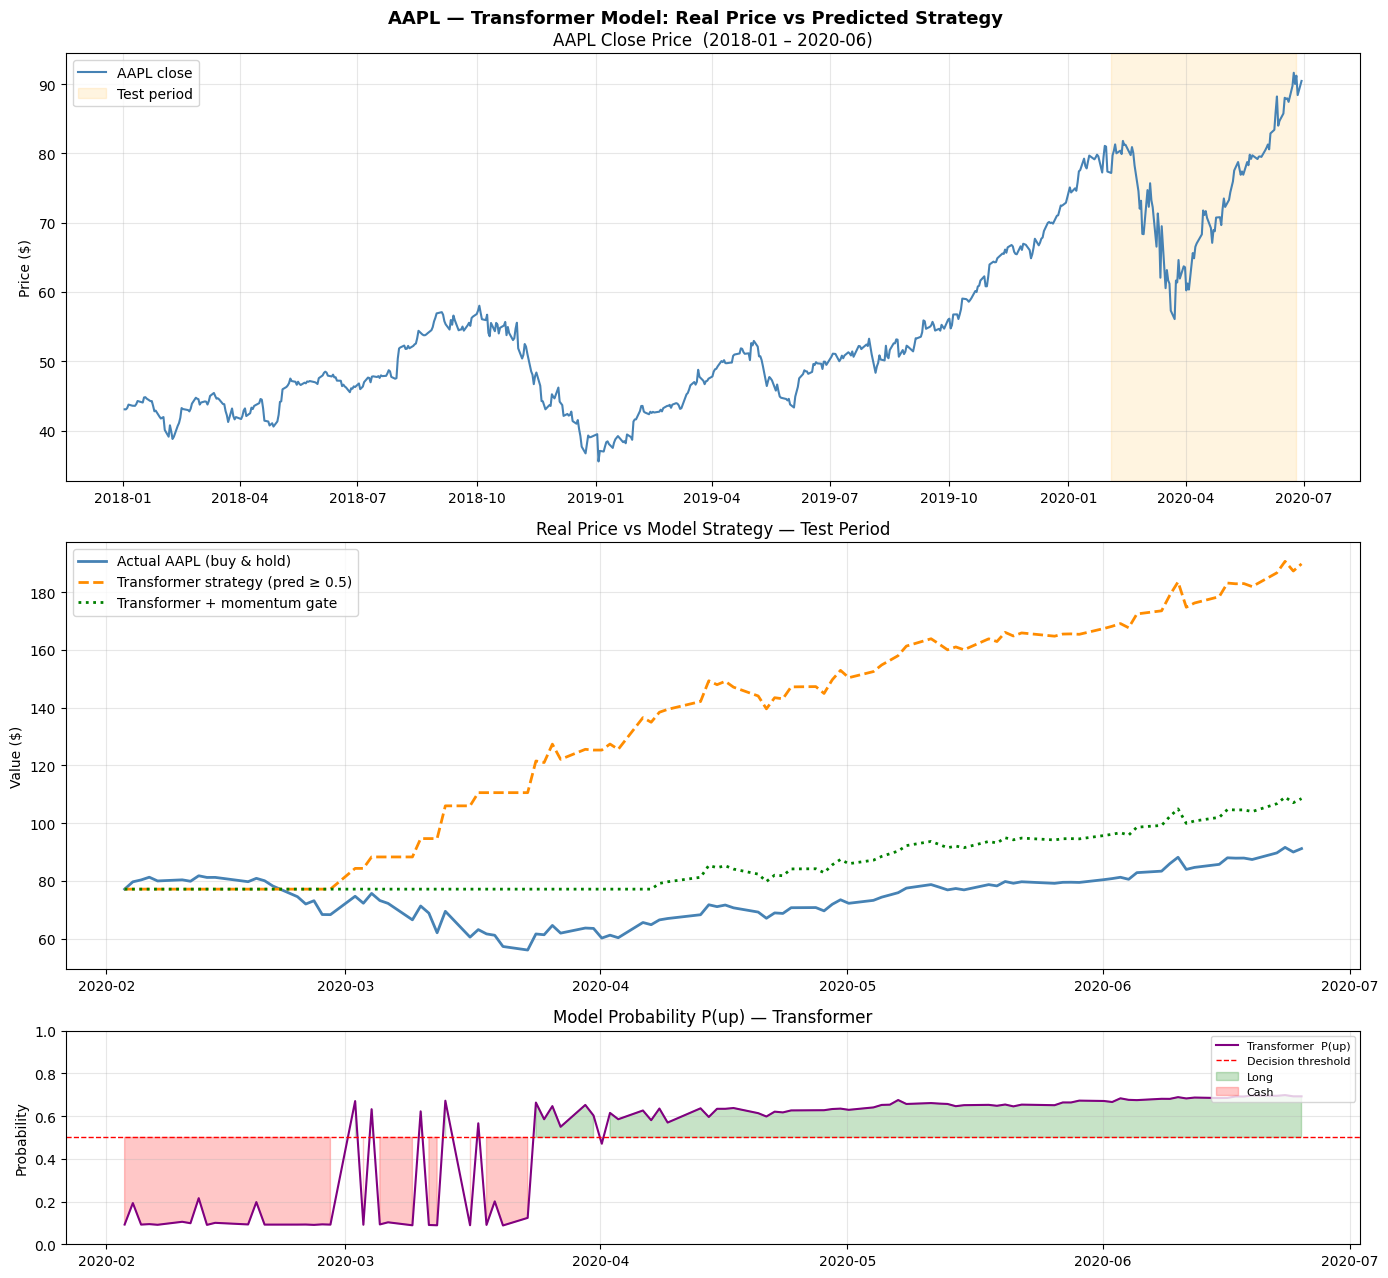


Test period starting price : $77.17
Actual AAPL (buy & hold)   : $91.21  (+18.2%)
Transformer strategy        : $189.79  (+145.9%)
Transformer + momentum gate : $108.52  (+40.6%)

Test AUC : 0.7093
Test Acc : 0.7030


In [25]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13),
                          gridspec_kw={"height_ratios": [2, 2, 1]})
fig.suptitle(
    f"AAPL — {best_name} Model: Real Price vs Predicted Strategy",
    fontsize=13, fontweight="bold"
)

# Panel 1: full AAPL close price with test period shaded
axes[0].plot(full_close.index, full_close.values, color="steelblue",
             linewidth=1.5, label="AAPL close")
axes[0].axvspan(actual_test_prices.index[0], actual_test_prices.index[-1],
                alpha=0.12, color="orange", label="Test period")
axes[0].set_title("AAPL Close Price  (2018-01 – 2020-06)")
axes[0].set_ylabel("Price ($)")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Panel 2: actual price vs strategy values in test period
axes[1].plot(actual_test_prices.index, actual_vals, color="steelblue",
             linewidth=2, label="Actual AAPL (buy & hold)")
axes[1].plot(actual_test_prices.index, strat_vals, color="darkorange",
             linewidth=2, linestyle="--",
             label=f"{best_name} strategy (pred ≥ 0.5)")
axes[1].plot(actual_test_prices.index, gated_vals, color="green",
             linewidth=2, linestyle=":",
             label=f"{best_name} + momentum gate")
axes[1].set_title("Real Price vs Model Strategy — Test Period")
axes[1].set_ylabel("Value ($)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: model probability with long/cash shading
axes[2].plot(actual_test_prices.index, best_probs, color="purple",
             linewidth=1.5, label=f"{best_name}  P(up)")
axes[2].axhline(0.5, color="red", linestyle="--", linewidth=1,
                label="Decision threshold")
axes[2].fill_between(
    actual_test_prices.index, 0.5, best_probs,
    where=(best_probs >= 0.5), alpha=0.22, color="green", label="Long"
)
axes[2].fill_between(
    actual_test_prices.index, best_probs, 0.5,
    where=(best_probs < 0.5), alpha=0.22, color="red", label="Cash"
)
axes[2].set_ylim(0, 1)
axes[2].set_title(f"Model Probability P(up) — {best_name}")
axes[2].set_ylabel("Probability")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance summary
ret_actual = (actual_vals[-1] / p0 - 1) * 100
ret_strat  = (strat_vals[-1]  / p0 - 1) * 100
ret_gated  = (gated_vals[-1]  / p0 - 1) * 100
test_auc   = float(roc_auc_score(targets_arr, best_probs))
test_acc   = float(accuracy_score(targets_arr, preds))

print(f"\nTest period starting price : ${p0:.2f}")
print(f"Actual AAPL (buy & hold)   : ${actual_vals[-1]:.2f}  ({ret_actual:+.1f}%)")
print(f"{best_name} strategy        : ${strat_vals[-1]:.2f}  ({ret_strat:+.1f}%)")
print(f"{best_name} + momentum gate : ${gated_vals[-1]:.2f}  ({ret_gated:+.1f}%)")
print(f"\nTest AUC : {test_auc:.4f}")
print(f"Test Acc : {test_acc:.4f}")